In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms 
import matplotlib.pyplot as plt
import numpy as np
from typing import List
from pathlib import Path
import os
import nbformat

from model.image_dataset import ImageDataset
from src.data_manager import DataManager

In [2]:
transform = transforms.Compose([
    transforms.Resize(size=(224, 224)), # TODO w pacy mamy chyba 300x300,
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    # transforms.Normalize(mean=count_mean(), std=count_std()) # TODO dodac normalizacje
])



In [3]:
# data_dir = os.path.join(os.getcwd(), "data", "processed")
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
data_dir = os.path.join(parent_dir, "data", "processed")

train_path = Path(os.path.join(data_dir, "train"))
test_path = Path(os.path.join(data_dir, "test"))
val_path = Path(os.path.join(data_dir, "val"))
# print(train_path)

train_dataset = ImageDataset(train_path, transform)
test_dataset = ImageDataset(test_path, transform)
val_dataset = ImageDataset(val_path, transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [4]:
print(len(train_dataset))
print(len(test_dataset))
print(len(val_dataset))
# 174144

174140
21879
24477


tensor(1)


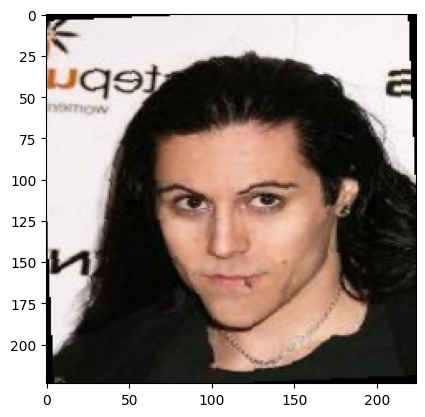

In [63]:
for images, labeles in train_loader:
    image = images[0].permute(1, 2, 0).numpy()
    plt.imshow(image)
    print(labeles[0])
    break